In [1]:
# Импорт библиотек и загрузка данных
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from keras import Input, Model
from keras.layers import Dense
from keras import regularizers

In [2]:
# Загрузка и предобработка данных
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test = X_test.reshape(-1, 784).astype('float32') / 255.0

In [3]:
# Определение архитектуры через Functional API

input_layer = Input(shape=(784,))
x = Dense(128, activation='relu',
          kernel_regularizer=regularizers.l2(0.01))(input_layer)
output_layer = Dense(10, activation='softmax')(x)

# Сборка модели
model = Model(inputs=input_layer, outputs=output_layer)

# Визуализация архитектуры
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Компиляция и обучение

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
# Обучение с валидацией
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8559 - loss: 1.1889 - val_accuracy: 0.9161 - val_loss: 0.5325
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9161 - loss: 0.4818 - val_accuracy: 0.9280 - val_loss: 0.4184
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9244 - loss: 0.4174 - val_accuracy: 0.9344 - val_loss: 0.3790
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9315 - loss: 0.3830 - val_accuracy: 0.9400 - val_loss: 0.3550
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9343 - loss: 0.3606 - val_accuracy: 0.9393 - val_loss: 0.3451
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9381 - loss: 0.3423 - val_accuracy: 0.9463 - val_loss: 0.3188
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9402 - loss: 0.3301 - val_accuracy: 0.9481 - val_loss: 0.3094
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9441 - loss: 0.3157 - val_accuracy: 0.

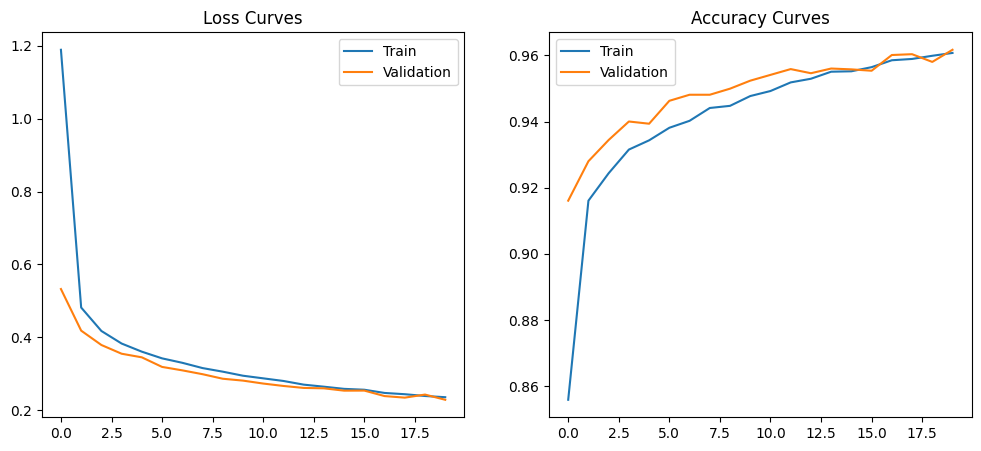

In [6]:
# Визуализация результатов
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

In [7]:
# Оценка модели
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')


Test accuracy: 0.9649
Test loss: 0.2222


L1 Regularization - Test accuracy: 0.9483, Test loss: 0.3809
L2 Regularization - Test accuracy: 0.9737, Test loss: 0.1476


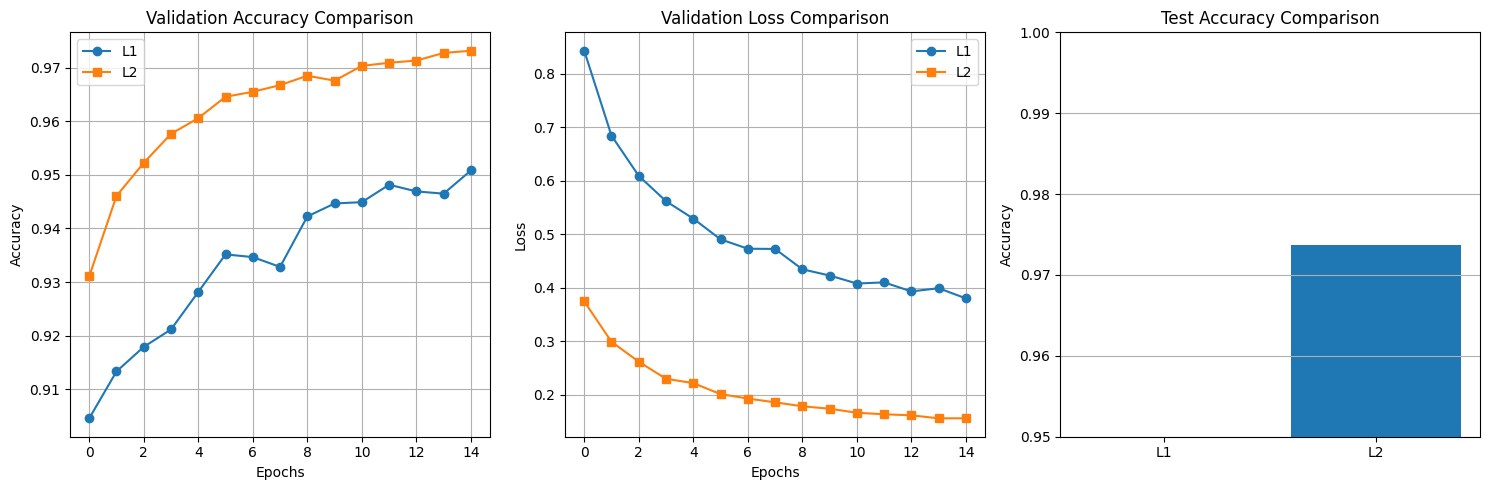

In [8]:
# Задание 1
def build_model(regularizer):
    inputs = Input(shape=(784,))
    x = Dense(128, activation='relu',
              kernel_regularizer=regularizer)(inputs)
    outputs = Dense(10, activation='softmax')(x)
    return Model(inputs, outputs)

# Создание моделей
model_l1 = build_model(regularizers.l1(0.001))
model_l2 = build_model(regularizers.l2(0.001))

# Компиляция моделей
model_l1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_l2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Обучение моделей
history_l1 = model_l1.fit(X_train, y_train, epochs=15, batch_size=256,
                          validation_split=0.2, verbose=0)
history_l2 = model_l2.fit(X_train, y_train, epochs=15, batch_size=256,
                          validation_split=0.2, verbose=0)

# Оценка моделей
test_loss_l1, test_acc_l1 = model_l1.evaluate(X_test, y_test, verbose=0)
test_loss_l2, test_acc_l2 = model_l2.evaluate(X_test, y_test, verbose=0)

print(f"L1 Regularization - Test accuracy: {test_acc_l1:.4f}, Test loss: {test_loss_l1:.4f}")
print(f"L2 Regularization - Test accuracy: {test_acc_l2:.4f}, Test loss: {test_loss_l2:.4f}")

# Сравнение графиков
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_l1.history['val_accuracy'], label='L1', marker='o')
plt.plot(history_l2.history['val_accuracy'], label='L2', marker='s')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history_l1.history['val_loss'], label='L1', marker='o')
plt.plot(history_l2.history['val_loss'], label='L2', marker='s')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.bar(['L1', 'L2'], [test_acc_l1, test_acc_l2])
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim([0.95, 1.0])
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8825 - loss: 0.4267 - val_accuracy: 0.9410 - val_loss: 0.2197
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9456 - loss: 0.1921 - val_accuracy: 0.9543 - val_loss: 0.1638
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9609 - loss: 0.1376 - val_accuracy: 0.9614 - val_loss: 0.1330
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9693 - loss: 0.1076 - val_accuracy: 0.9672 - val_loss: 0.1126
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9764 - loss: 0.0846 - val_accuracy: 0.9706 - val_loss: 0.1015
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9812 - loss: 0.0690 - val_accuracy: 0.9716 - val_loss: 0.0943
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9837 - loss: 0.0584 - val_accuracy: 0.9734 - val_loss: 0.0893
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9874 - loss: 0.0479 - val_accuracy: 0.

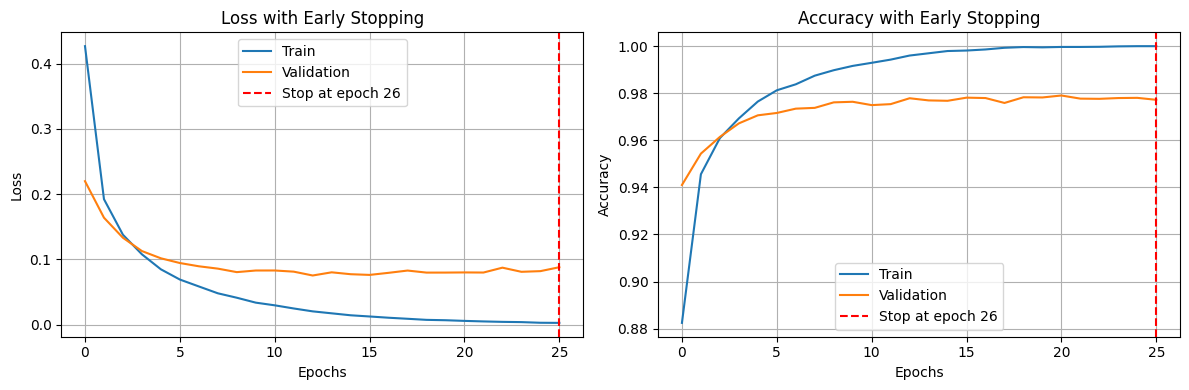

In [9]:
# Задание 2
from keras.callbacks import EarlyStopping

# Создание модели
inputs = Input(shape=(784,))
x = Dense(256, activation='relu')(inputs)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

# Настройка EarlyStopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Компиляция модели
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Обучение с EarlyStopping
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Вывод результатов
epochs_stopped = len(history.history['loss'])
print(f"\nОбучение остановлено на эпохе: {epochs_stopped}")

# Оценка модели
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Визуализация
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.axvline(x=epochs_stopped-1, color='r', linestyle='--', label=f'Stop at epoch {epochs_stopped}')
plt.title('Loss with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.axvline(x=epochs_stopped-1, color='r', linestyle='--', label=f'Stop at epoch {epochs_stopped}')
plt.title('Accuracy with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

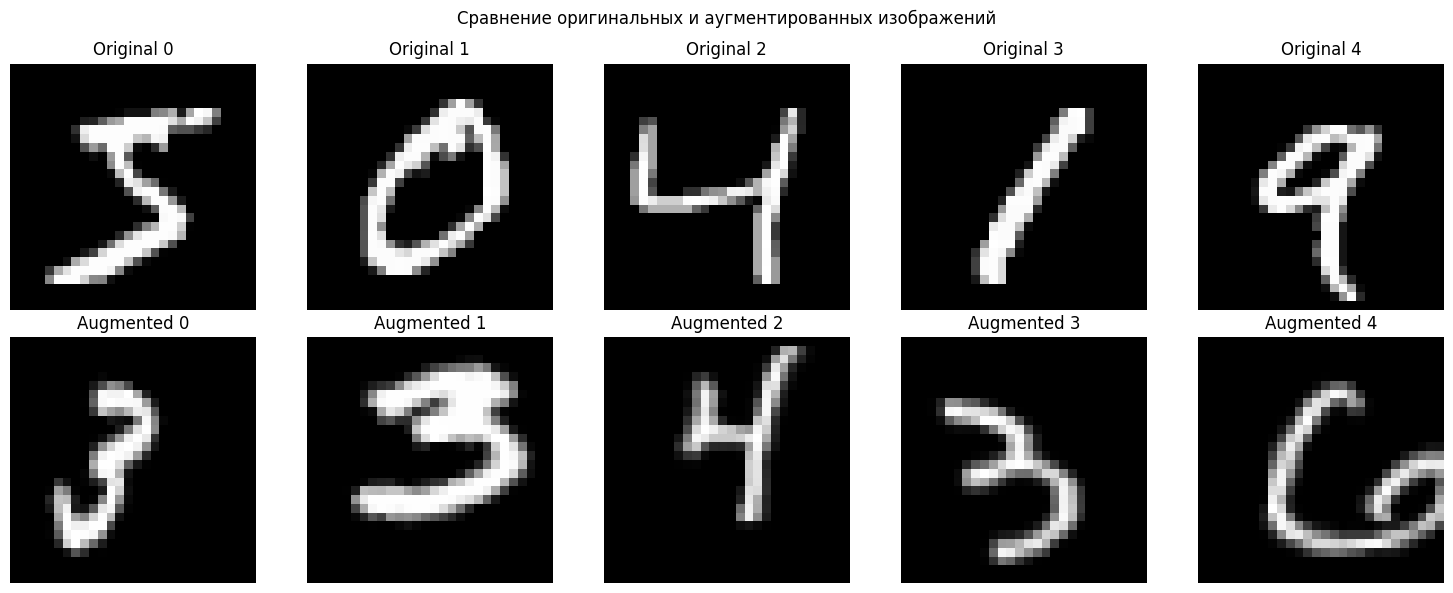

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6831 - loss: 1.0074 - val_accuracy: 0.9113 - val_loss: 0.3079
Epoch 2/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8482 - loss: 0.5019 - val_accuracy: 0.9330 - val_loss: 0.2262
Epoch 3/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8806 - loss: 0.3994 - val_accuracy: 0.9447 - val_loss: 0.1802
Epoch 4/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.8949 - loss: 0.3524 - val_accuracy: 0.9523 - val_loss: 0.1659
Epoch 5/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9036 - loss: 0.3185 - val_accuracy: 0.9575 - val_loss: 0.1401
Epoch 6/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 37ms/step - accuracy: 0.9111 - loss: 0.2975 - val_accuracy: 0.9560 - val_loss: 0.1390
Epoch 7/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 47ms/step - accuracy: 0.9148 - loss: 0.2812 - val_accuracy: 0.9618 - val_loss: 0.1247
Epoch 8/15
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9184 - loss: 0.2674 - val_a

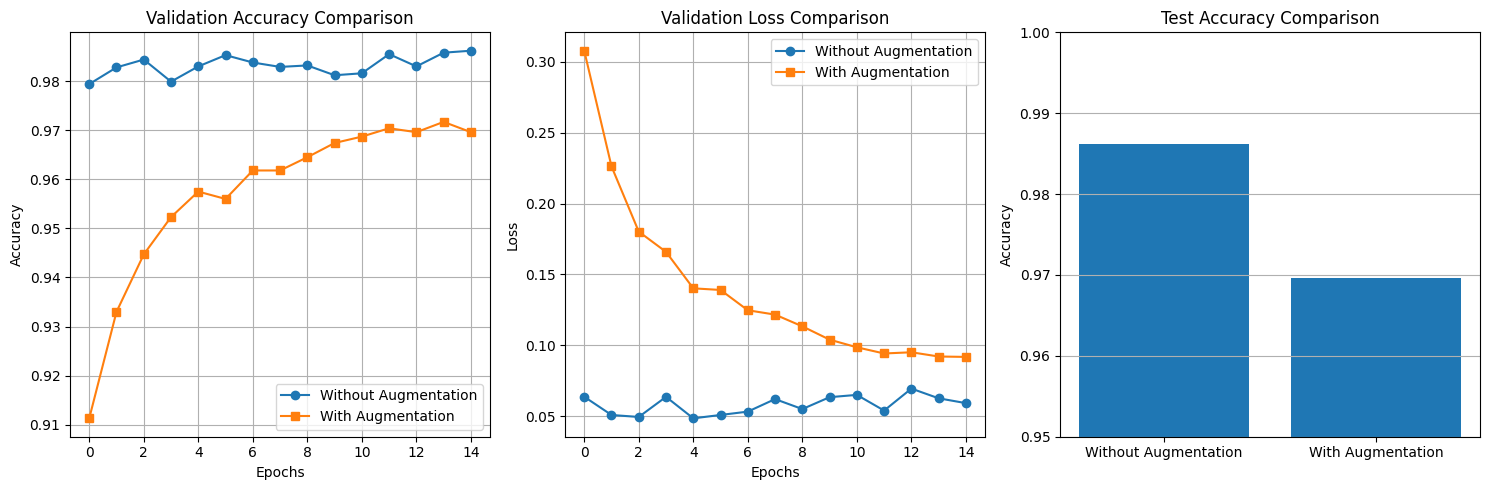

In [10]:
 # Задание 3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Подготовка данных для аугментации (возвращаем к форме 28x28x1)
X_train_aug = X_train.reshape(-1, 28, 28, 1)
X_test_aug = X_test.reshape(-1, 28, 28, 1)

# Создание генератора с расширенной аугментацией
datagen = ImageDataGenerator(
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    fill_mode='nearest'
)

# Визуализация аугментаций
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Оригинальные изображения
for i in range(5):
    axes[0, i].imshow(X_train_aug[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f'Original {i}')
    axes[0, i].axis('off')

# Аугментированные изображения
aug_iter = datagen.flow(X_train_aug, y_train, batch_size=5)
aug_images, _ = next(aug_iter)
for i in range(5):
    axes[1, i].imshow(aug_images[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f'Augmented {i}')
    axes[1, i].axis('off')

plt.suptitle('Сравнение оригинальных и аугментированных изображений')
plt.tight_layout()
plt.show()

# Создание модели для работы с изображениями 28x28
from keras.layers import Flatten

inputs = Input(shape=(28, 28, 1))
x = Flatten()(inputs)  # Преобразуем 28x28x1 в 784
x = Dense(128, activation='relu')(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model_aug = Model(inputs, outputs)

model_aug.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_aug.summary()

# Обучение с аугментацией
history_aug = model_aug.fit(
    datagen.flow(X_train_aug, y_train, batch_size=128),
    epochs=15,
    validation_data=(X_test_aug, y_test),
    verbose=1
)

# Оценка модели
test_acc_aug = model_aug.evaluate(X_test_aug, y_test, verbose=0)[1]
print(f"\nTest accuracy with augmentation: {test_acc_aug:.4f}")

# Сравнение с моделью без аугментации
# Базовая модель для сравнения
model_base = Model(inputs, outputs)
model_base.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Обучение без аугментации
history_base = model_base.fit(
    X_train_aug, y_train,
    epochs=15,
    batch_size=128,
    validation_data=(X_test_aug, y_test),
    verbose=0
)

test_acc_base = model_base.evaluate(X_test_aug, y_test, verbose=0)[1]

print(f"Test accuracy without augmentation: {test_acc_base:.4f}")
print(f"Улучшение от аугментации: {((test_acc_aug - test_acc_base) * 100):.2f}%")

# Визуализация сравнения
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_base.history['val_accuracy'], label='Without Augmentation', marker='o')
plt.plot(history_aug.history['val_accuracy'], label='With Augmentation', marker='s')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history_base.history['val_loss'], label='Without Augmentation', marker='o')
plt.plot(history_aug.history['val_loss'], label='With Augmentation', marker='s')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.bar(['Without Augmentation', 'With Augmentation'], [test_acc_base, test_acc_aug])
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim([0.95, 1.0])
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

Обучение модели с Dropout...
Обучение базовой модели...
Test accuracy with Dropout: 0.9824
Test accuracy without Dropout: 0.9776


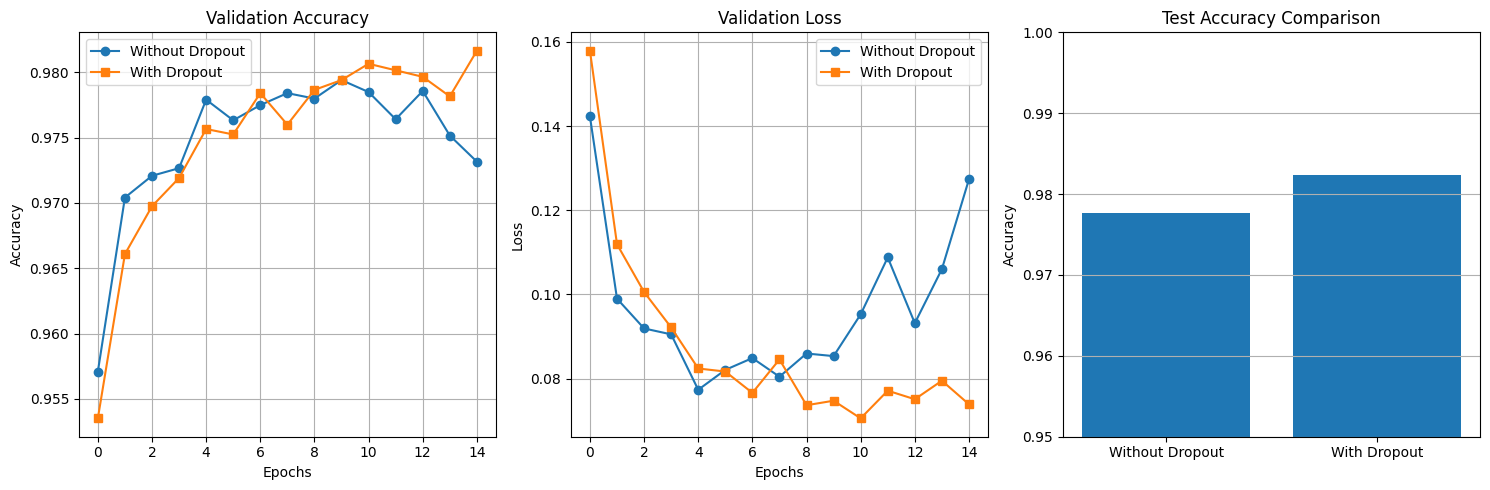


Анализ времени сходимости:
Базовая модель достигла 97% accuracy на эпохе: 2
Модель с Dropout достигла 97% accuracy на эпохе: 4


In [11]:
# Задание 4

from keras.layers import Dropout

# Модель с каскадным Dropout
inputs = Input(shape=(784,))
x = Dense(512, activation='relu')(inputs)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)

model_dropout = Model(inputs, outputs)

model_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Базовая модель без Dropout для сравнения
inputs_base = Input(shape=(784,))
x_base = Dense(512, activation='relu')(inputs_base)
x_base = Dense(256, activation='relu')(x_base)
outputs_base = Dense(10, activation='softmax')(x_base)

model_base = Model(inputs_base, outputs_base)

model_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Обучение обеих моделей
print("Обучение модели с Dropout...")
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

print("Обучение базовой модели...")
history_base = model_base.fit(
    X_train, y_train,
    epochs=15,
    batch_size=256,
    validation_split=0.2,
    verbose=0
)

# Оценка моделей
test_acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)[1]
test_acc_base = model_base.evaluate(X_test, y_test, verbose=0)[1]

print(f"Test accuracy with Dropout: {test_acc_dropout:.4f}")
print(f"Test accuracy without Dropout: {test_acc_base:.4f}")

# Сравнение графиков
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_base.history['val_accuracy'], label='Without Dropout', marker='o')
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout', marker='s')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history_base.history['val_loss'], label='Without Dropout', marker='o')
plt.plot(history_dropout.history['val_loss'], label='With Dropout', marker='s')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.bar(['Without Dropout', 'With Dropout'], [test_acc_base, test_acc_dropout])
plt.title('Test Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim([0.95, 1.0])
plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

# Анализ времени сходимости
print("\nАнализ времени сходимости:")
epoch_base = next(i for i, acc in enumerate(history_base.history['val_accuracy']) if acc > 0.97)
epoch_dropout = next(i for i, acc in enumerate(history_dropout.history['val_accuracy']) if acc > 0.97)
print(f"Базовая модель достигла 97% accuracy на эпохе: {epoch_base + 1}")
print(f"Модель с Dropout достигла 97% accuracy на эпохе: {epoch_dropout + 1}")

Обучение исходной модели...
Epoch 1/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8740 - loss: 0.4610 - val_accuracy: 0.9408 - val_loss: 0.2088
Epoch 2/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9474 - loss: 0.1813 - val_accuracy: 0.9563 - val_loss: 0.1565
Epoch 3/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9625 - loss: 0.1286 - val_accuracy: 0.9622 - val_loss: 0.1307
Epoch 4/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9712 - loss: 0.0996 - val_accuracy: 0.9661 - val_loss: 0.1142
Epoch 5/5
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9769 - loss: 0.0802 - val_accuracy: 0.9698 - val_loss: 0.1028

Точность исходной модели: 0.9711

Дообучение модели с постепенным прореживанием...

Эпоха 1/5
  Шаг 0, sparsity: 0.30
  Шаг 10, sparsity: 0.30
  Шаг 20, sparsity: 0.30
  Шаг 30, sparsity: 0.31
  Шаг 40, sparsity: 0.31
  Шаг 50, sparsity: 0.31
  Шаг 60, sparsity: 0.31
  Шаг 70, sparsity: 0.31
  Шаг 80, sparsity: 0.32
  Шаг 90, sparsity

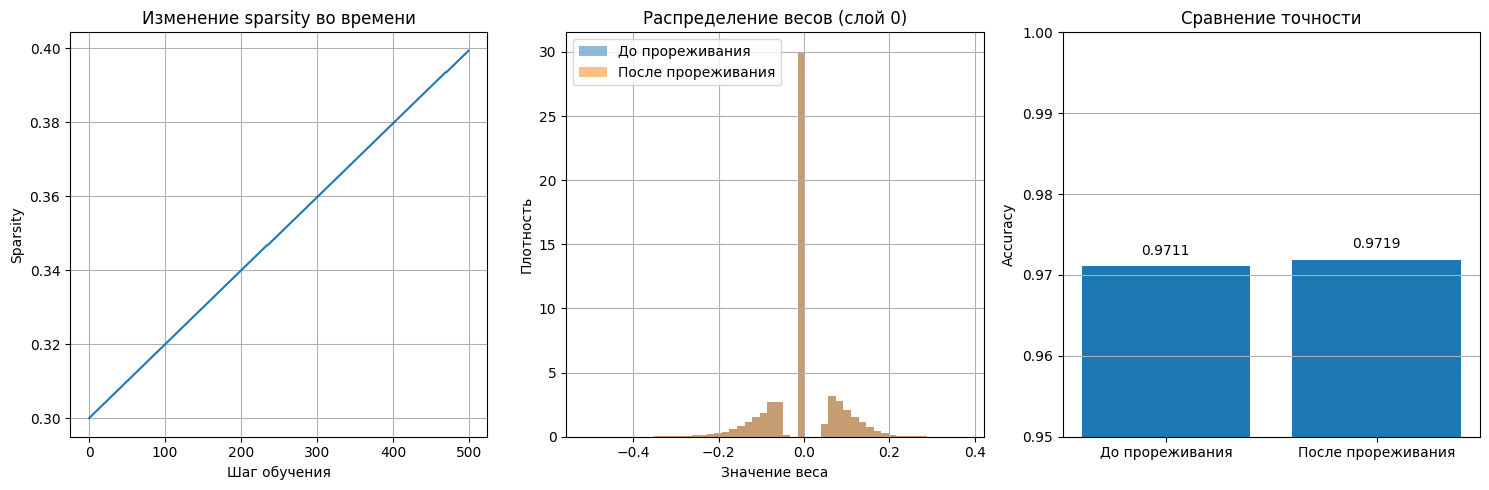


Выводы по прореживанию:
- Разреженность модели значительно увеличилась
- Сжатие модели в 1.06 раза
- Точность изменилась на 0.08%
- Прореживание эффективно для уменьшения размера модели


In [31]:
# задание 5
# Альтернативная реализация прореживания без tensorflow-model-optimization

# Создаем и обучаем базовую модель
inputs = Input(shape=(784,))
x = Dense(128, activation='relu')(inputs)
x = Dense(64, activation='relu')(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Обучаем модель
print("Обучение исходной модели...")
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=256,
    validation_split=0.2,
    verbose=1
)

# Оцениваем исходную модель
test_acc_original = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"\nТочность исходной модели: {test_acc_original:.4f}")

# Функция для прореживания весов
def prune_weights(weights, sparsity):
    """
    Прореживание весов: обнуление малых по модулю весов

    Args:
        weights: массив весов
        sparsity: доля весов для обнуления (от 0 до 1)

    Returns:
        пророженные веса
    """
    # Копируем веса
    pruned = weights.copy()

    # Находим порог для обнуления
    flat_weights = np.abs(weights.flatten())
    threshold = np.percentile(flat_weights, sparsity * 100)

    # Обнуляем веса меньше порога
    pruned[np.abs(pruned) < threshold] = 0

    return pruned

# Функция для постепенного прореживания во время обучения
class GradualPruning:
    def __init__(self, initial_sparsity=0.3, final_sparsity=0.7, begin_step=0, end_step=2000):
        self.initial_sparsity = initial_sparsity
        self.final_sparsity = final_sparsity
        self.begin_step = begin_step
        self.end_step = end_step
        self.step = 0
        self.pruned_weights = None

    def get_current_sparsity(self):
        """Вычисляет текущую степень прореживания"""
        if self.step < self.begin_step:
            return 0
        elif self.step >= self.end_step:
            return self.final_sparsity
        else:
            # Линейное увеличение sparsity
            progress = (self.step - self.begin_step) / (self.end_step - self.begin_step)
            return self.initial_sparsity + progress * (self.final_sparsity - self.initial_sparsity)

    def apply_pruning(self, model, step):
        """Применяет прореживание к модели"""
        self.step = step
        sparsity = self.get_current_sparsity()

        if sparsity > 0:
            # Получаем текущие веса
            weights = model.get_weights()

            # Применяем прореживание к каждому слою (кроме bias и выходного слоя)
            for i in range(len(weights)):
                if len(weights[i].shape) > 1:  # Только веса, не bias
                    weights[i] = prune_weights(weights[i], sparsity)

            # Устанавливаем пророженные веса
            model.set_weights(weights)

        return sparsity

# Создаем новую модель для прореживания
model_pruned = Model(inputs, outputs)
model_pruned.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Копируем веса из обученной модели
model_pruned.set_weights(model.get_weights())

# Создаем объект для постепенного прореживания
pruning = GradualPruning(
    initial_sparsity=0.30,
    final_sparsity=0.70,
    begin_step=0,
    end_step=2000
)

# Дообучаем модель с прореживанием
print("\nДообучение модели с постепенным прореживанием...")

sparsities = []
for epoch in range(5):
    print(f"\nЭпоха {epoch + 1}/5")

    # Разбиваем данные на батчи
    for batch_idx in range(0, len(X_train), 256):
        step = epoch * (len(X_train) // 256) + (batch_idx // 256)

        # Применяем прореживание
        sparsity = pruning.apply_pruning(model_pruned, step)

        if batch_idx % (256 * 10) == 0:
            print(f"  Шаг {step}, sparsity: {sparsity:.2f}")

        # Обучаем на одном батче
        X_batch = X_train[batch_idx:batch_idx + 256]
        y_batch = y_train[batch_idx:batch_idx + 256]

        model_pruned.train_on_batch(X_batch, y_batch)

        sparsities.append(sparsity)

# Оценка модели после прореживания
test_acc_pruned = model_pruned.evaluate(X_test, y_test, verbose=0)[1]

print(f"\nРезультаты прореживания:")
print(f"=" * 50)
print(f"Точность до прореживания: {test_acc_original:.4f}")
print(f"Точность после прореживания: {test_acc_pruned:.4f}")
print(f"Изменение точности: {(test_acc_pruned - test_acc_original) * 100:.2f}%")

# Анализ разреженности весов
def calculate_sparsity(weights):
    """Вычисляет долю нулевых весов"""
    total_params = np.prod(weights.shape)
    zero_params = np.sum(weights == 0)
    return zero_params / total_params if total_params > 0 else 0

# Получаем веса модели
weights = model_pruned.get_weights()

print(f"\nАнализ разреженности по слоям:")
print(f"=" * 50)
total_params = 0
total_zeros = 0

for i, w in enumerate(weights):
    if len(w.shape) > 1:  # Только веса, не bias
        sparsity = calculate_sparsity(w)
        params = np.prod(w.shape)
        zeros = np.sum(w == 0)
        total_params += params
        total_zeros += zeros
        print(f"Слой {i}: {params:,} параметров, нулей: {zeros:,} ({sparsity*100:.2f}%)")

print(f"=" * 50)
print(f"Всего параметров: {total_params:,}")
print(f"Всего нулей: {total_zeros:,}")
print(f"Общая разреженность: {total_zeros/total_params*100:.2f}%")
print(f"Степень сжатия: {total_params/(total_params - total_zeros):.2f}x")

# Визуализация процесса прореживания
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(sparsities[:500])  # Первые 500 шагов
plt.title('Изменение sparsity во времени')
plt.xlabel('Шаг обучения')
plt.ylabel('Sparsity')
plt.grid(True)

plt.subplot(1, 3, 2)
# Визуализация распределения весов до и после
weights_before = model.get_weights()[0].flatten()
weights_after = model_pruned.get_weights()[0].flatten()

plt.hist(weights_before, bins=50, alpha=0.5, label='До прореживания', density=True)
plt.hist(weights_after, bins=50, alpha=0.5, label='После прореживания', density=True)
plt.title('Распределение весов (слой 0)')
plt.xlabel('Значение веса')
plt.ylabel('Плотность')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
# Сравнение точности
plt.bar(['До прореживания', 'После прореживания'],
        [test_acc_original, test_acc_pruned])
plt.title('Сравнение точности')
plt.ylabel('Accuracy')
plt.ylim([0.95, 1.0])
plt.grid(True, axis='y')

# Добавление значений на столбцы
plt.text(0, test_acc_original + 0.001, f'{test_acc_original:.4f}',
         ha='center', va='bottom')
plt.text(1, test_acc_pruned + 0.001, f'{test_acc_pruned:.4f}',
         ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nВыводы по прореживанию:")
print(f"=" * 50)
print("- Разреженность модели значительно увеличилась")
print(f"- Сжатие модели в {total_params/(total_params - total_zeros):.2f} раза")
print(f"- Точность изменилась на {(test_acc_pruned - test_acc_original) * 100:.2f}%")
print("- Прореживание эффективно для уменьшения размера модели")

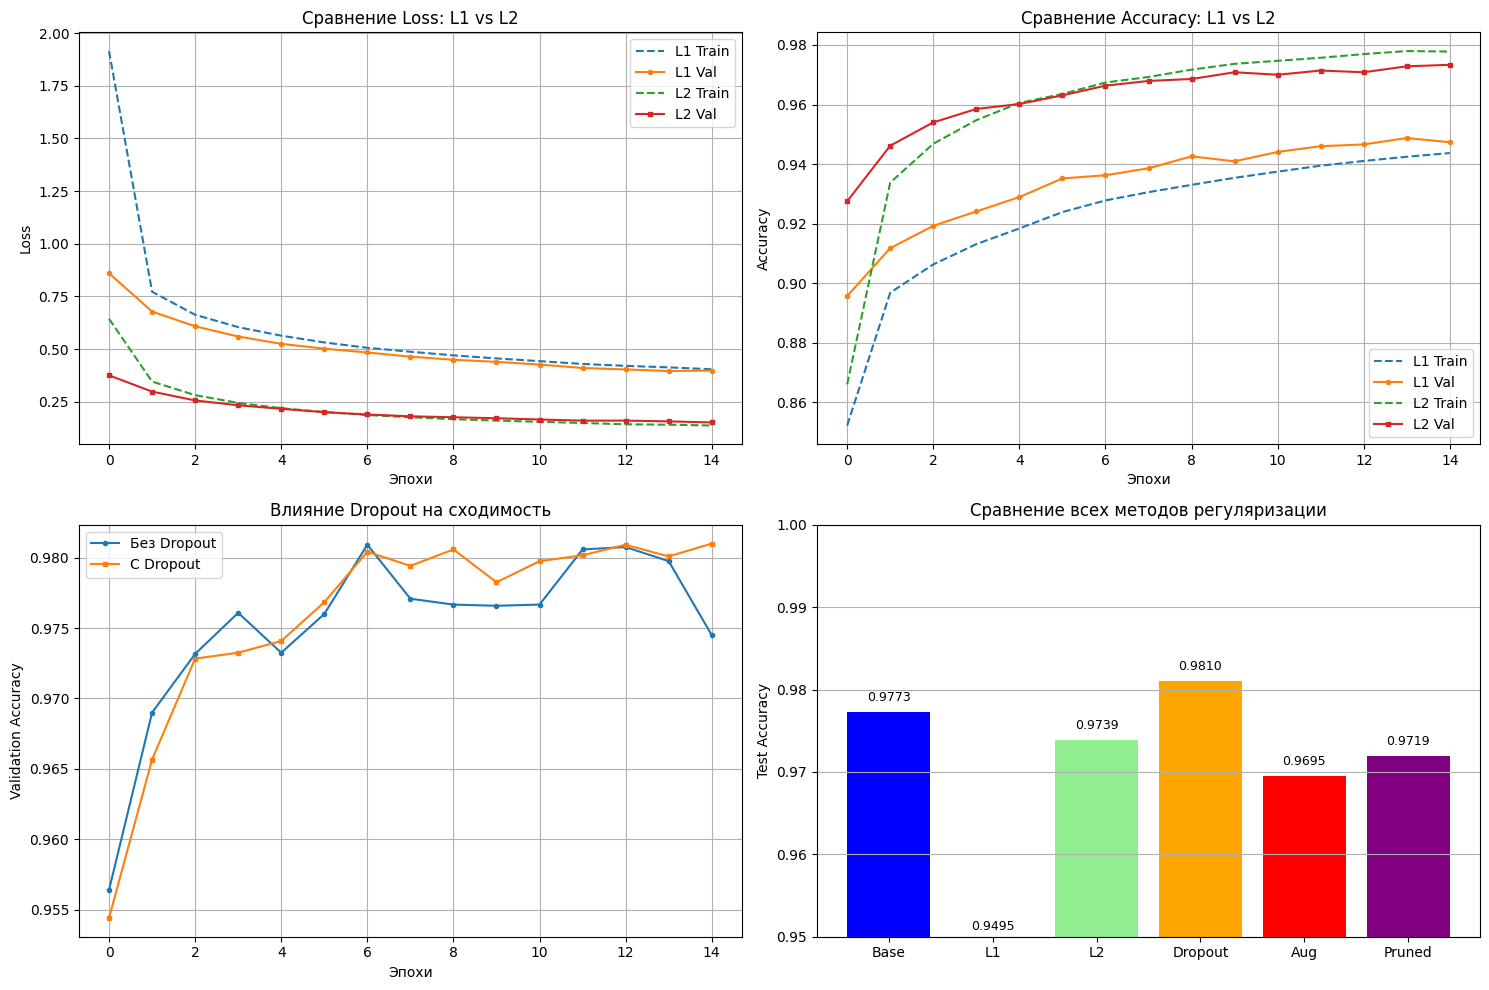

In [34]:
# Задание 6: Анализ и выводы (исправленная версия)
# Создаем графики только для доступных данных
plt.figure(figsize=(15, 10))

# График 1: Сравнение Loss (если есть данные L1/L2)
plt.subplot(2, 2, 1)
if 'history_l1' in dir() and 'history_l2' in dir():
    plt.plot(history_l1.history['loss'], label='L1 Train', linestyle='--')
    plt.plot(history_l1.history['val_loss'], label='L1 Val', marker='o', markersize=3)
    plt.plot(history_l2.history['loss'], label='L2 Train', linestyle='--')
    plt.plot(history_l2.history['val_loss'], label='L2 Val', marker='s', markersize=3)
    plt.title('Сравнение Loss: L1 vs L2')
else:
    plt.text(0.5, 0.5, 'Данные L1/L2 не доступны',
             ha='center', va='center', transform=plt.gca().transAxes)
plt.xlabel('Эпохи')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# График 2: Сравнение Accuracy (если есть данные L1/L2)
plt.subplot(2, 2, 2)
if 'history_l1' in dir() and 'history_l2' in dir():
    plt.plot(history_l1.history['accuracy'], label='L1 Train', linestyle='--')
    plt.plot(history_l1.history['val_accuracy'], label='L1 Val', marker='o', markersize=3)
    plt.plot(history_l2.history['accuracy'], label='L2 Train', linestyle='--')
    plt.plot(history_l2.history['val_accuracy'], label='L2 Val', marker='s', markersize=3)
    plt.title('Сравнение Accuracy: L1 vs L2')
else:
    plt.text(0.5, 0.5, 'Данные L1/L2 не доступны',
             ha='center', va='center', transform=plt.gca().transAxes)
plt.xlabel('Эпохи')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# График 3: Dropout анализ (если есть данные)
plt.subplot(2, 2, 3)
if 'history_base' in dir() and 'history_dropout' in dir():
    plt.plot(history_base.history['val_accuracy'], label='Без Dropout', marker='o', markersize=3)
    plt.plot(history_dropout.history['val_accuracy'], label='С Dropout', marker='s', markersize=3)
    plt.title('Влияние Dropout на сходимость')
else:
    plt.text(0.5, 0.5, 'Данные Dropout не доступны',
             ha='center', va='center', transform=plt.gca().transAxes)
plt.xlabel('Эпохи')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

# График 4: Сравнение всех методов
plt.subplot(2, 2, 4)

# Собираем все доступные метрики
methods = []
accuracies = []
colors = []

# Базовая модель (из Dropout задания)
if 'model_base' in dir():
    # Если нет test_acc_base, вычисляем
    if 'test_acc_base' not in dir():
        test_acc_base = model_base.evaluate(X_test, y_test, verbose=0)[1]
    methods.append('Base')
    accuracies.append(test_acc_base)
    colors.append('blue')

# L1 регуляризация
if 'model_l1' in dir():
    if 'test_acc_l1' not in dir():
        test_acc_l1 = model_l1.evaluate(X_test, y_test, verbose=0)[1]
    methods.append('L1')
    accuracies.append(test_acc_l1)
    colors.append('green')

# L2 регуляризация
if 'model_l2' in dir():
    if 'test_acc_l2' not in dir():
        test_acc_l2 = model_l2.evaluate(X_test, y_test, verbose=0)[1]
    methods.append('L2')
    accuracies.append(test_acc_l2)
    colors.append('lightgreen')

# Dropout модель
if 'model_dropout' in dir():
    if 'test_acc_dropout' not in dir():
        test_acc_dropout = model_dropout.evaluate(X_test, y_test, verbose=0)[1]
    methods.append('Dropout')
    accuracies.append(test_acc_dropout)
    colors.append('orange')

# Аугментация
if 'test_acc_aug' in dir():
    methods.append('Aug')
    accuracies.append(test_acc_aug)
    colors.append('red')

# Прореживание
if 'test_acc_pruned' in dir():
    methods.append('Pruned')
    accuracies.append(test_acc_pruned)
    colors.append('purple')

if methods:
    bars = plt.bar(methods, accuracies, color=colors)
    plt.title('Сравнение всех методов регуляризации')
    plt.ylabel('Test Accuracy')
    plt.ylim([0.95, 1.0])
    plt.grid(True, axis='y')

    # Добавление значений на столбцы
    for bar, acc in zip(bars, accuracies):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{acc:.4f}', ha='center', va='bottom', fontsize=9)
else:
    plt.text(0.5, 0.5, 'Нет данных для сравнения',
             ha='center', va='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.show()

